In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import numpy as np
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import pmdarima as pm  
import warnings
import logging

#Load the data
df = pd.read_csv('airline_passengers.csv', parse_dates=['Month'], index_col='Month')

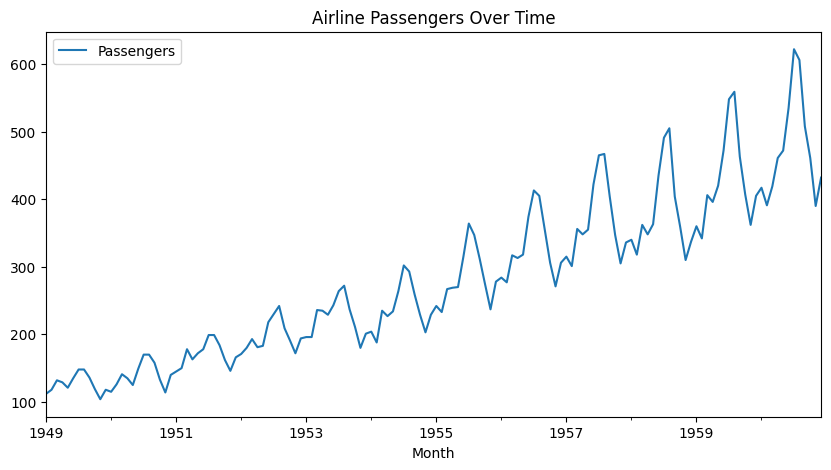

622
104
            Passengers
Month                 
1949-01-01         112
            Passengers
Month                 
1960-12-01         432


In [23]:
df.plot(figsize=(10, 5), title='Airline Passengers Over Time')
plt.show()
max = df['Passengers'].max()
print(max)

min = df['Passengers'].min()
print(min)
print(df.head(1))
print(df.tail(1))

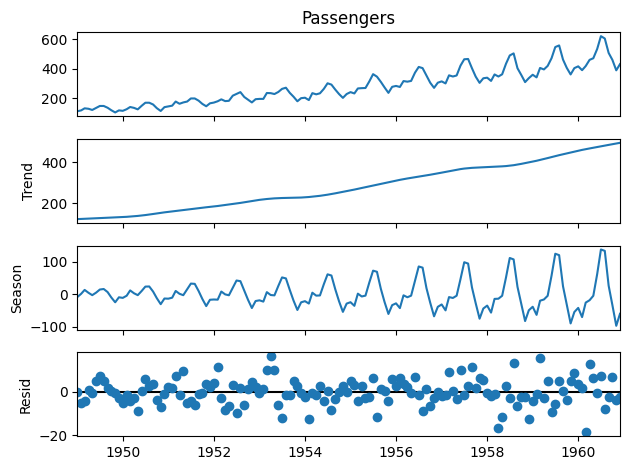

In [24]:
#Perform STL decomposition
stl = STL(df['Passengers'], seasonal=13)
result = stl.fit()

#Plot the decomposition
result.plot()
plt.show()

/home/joshmurray/.local/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


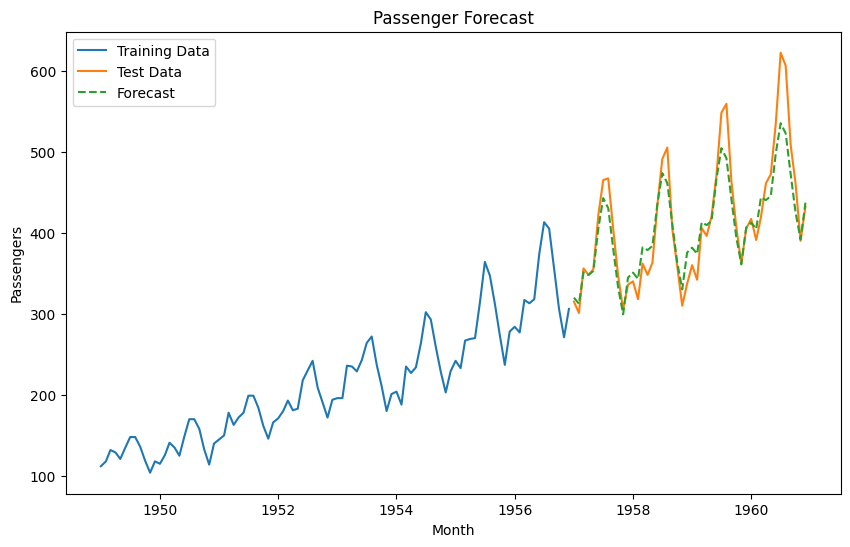

RMSE on test data: 28.57


In [25]:
# Split data into train and test (last 12 months for testing)
train = df[:-48]
test = df[-48:]

#Fit models on training data
model = ExponentialSmoothing(
    train['Passengers'],
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()

#Make forecast for test period
forecast = model.forecast(len(test))

#Plot everything
plt.figure(figsize=(10, 6))
plt.plot(train['Passengers'], label='Training Data')
plt.plot(test['Passengers'], label='Test Data')
plt.plot(test.index, forecast, label='Forecast', linestyle='--')
plt.title('Passenger Forecast')
plt.xlabel('Month')
plt.ylabel('Passengers')
plt.legend()
plt.show()

#Print accuracy for test period
rmse = np.sqrt(mean_squared_error(test['Passengers'], forecast))
print(f'RMSE on test data: {rmse:.2f}')

/home/joshmurray/.local/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/joshmurray/.local/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/joshmurray/.local/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


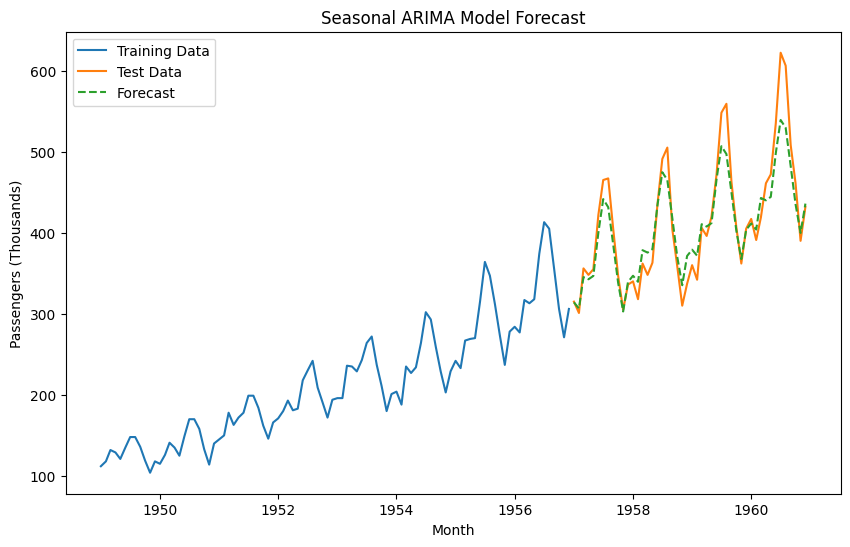

RMSE on test data: 26.47


In [26]:
# Split data into train and test (last 12 months for testing)
train = df[:-48]
test = df[-48:]

#Fit ARIMA model on training data with seasonal components
# ARIMA(p=2, d=1, q=2)(P=1, D=1, Q=1, s=12)
arima = ARIMA(train['Passengers'],
              order=(1,1,0),
              seasonal_order=(1,1,0,12)).fit()

# Make forecast for the test period (next 12 months)
forecast = arima.forecast(steps=len(test))

#Plot everything
plt.figure(figsize=(10, 6))
plt.plot(train['Passengers'], label='Training Data')
plt.plot(test['Passengers'], label='Test Data')
plt.plot(test.index, forecast, label='Forecast', linestyle='--')
plt.title('Seasonal ARIMA Model Forecast')
plt.xlabel('Month')
plt.ylabel('Passengers (Thousands)')
plt.legend()
plt.show()

#Print accuracy for test period
rmse = np.sqrt(mean_squared_error(test['Passengers'], forecast))
print(f'RMSE on test data: {rmse:.2f}')

In [27]:
warnings.filterwarnings("ignore", category=FutureWarning)

# Split Data: Train = all except last 48 months, Test = last 48 months
train = df.iloc[:-48]
test = df.iloc[-48:]

#Fit Auto ARIMA with detailed logging
model = pm.auto_arima(
    df['Passengers'],
    seasonal=True,
    m=12,  # Monthly data (seasonality=12 months)
    stepwise=True,
    suppress_warnings=True,  # Allow warnings to see potential issues
    trace=True,  # Enables logging of each model tested
    error_action='ignore',  # Ignore errors to keep process going
    maxiter=100  # Ensure enough iterations to log multiple models
)

#Print Summary of the Best Model
print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=1020.048, Time=0.40 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1031.508, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1020.393, Time=0.04 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1021.003, Time=0.06 sec
 ARIMA(2,1,2)(0,1,1)[12]             : AIC=1019.935, Time=0.23 sec
 ARIMA(2,1,2)(0,1,0)[12]             : AIC=1019.290, Time=0.08 sec
 ARIMA(2,1,2)(1,1,0)[12]             : AIC=1019.546, Time=0.22 sec
 ARIMA(1,1,2)(0,1,0)[12]             : AIC=1024.160, Time=0.04 sec
 ARIMA(2,1,1)(0,1,0)[12]             : AIC=1017.847, Time=0.06 sec
 ARIMA(2,1,1)(1,1,0)[12]             : AIC=1017.914, Time=0.20 sec
 ARIMA(2,1,1)(0,1,1)[12]             : AIC=1018.359, Time=0.18 sec
 ARIMA(2,1,1)(1,1,1)[12]             : AIC=1018.248, Time=0.38 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=1022.393, Time=0.03 sec
 ARIMA(2,1,0)(0,1,0)[12]             : AIC=1022.393, Time=0.03 sec
 ARIMA(3,1,1)(0,1,0

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=619.846, Time=0.22 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=622.012, Time=0.01 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=615.965, Time=0.04 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=616.628, Time=0.05 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=618.192, Time=0.02 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=617.814, Time=0.15 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=617.881, Time=0.10 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=616.531, Time=0.04 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=0.57 sec
 ARIMA(0,1,0)(1,1,0)[12]             : AIC=618.221, Time=0.03 sec
 ARIMA(2,1,0)(1,1,0)[12]             : AIC=617.862, Time=0.05 sec
 ARIMA(1,1,1)(1,1,0)[12]             : AIC=617.462, Time=0.06 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=616.076, Time=0.04 sec
 ARIMA(2,1,1)(1,1,0)[12]             : AIC=619.394, Time=0.11 sec
 ARIMA(1,1,0)(1,1,0)[12] intercept   

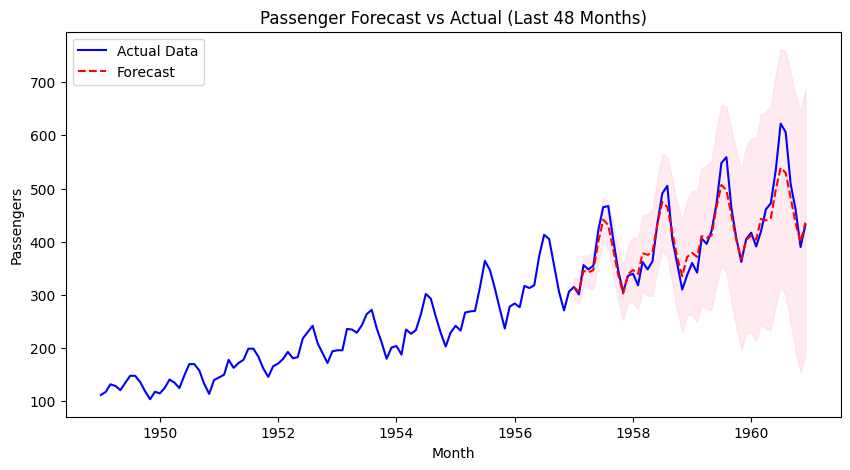

RMSE on test data: 26.47


In [28]:
import pmdarima as pm
import warnings
import pandas as pd
import logging
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import mean_squared_error

#Ignore warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Split Data: Train = all except last 48 months, Test = last 48 months
train = df.iloc[:-48]
test = df.iloc[-48:]

#Fit Auto ARIMA on Training Data
model = pm.auto_arima(
    train['Passengers'],
    seasonal=True,
    m=12,  # Monthly data (seasonality=12 months)
    stepwise=True,
    suppress_warnings=True,  
    trace=True,  # Enables logging of each model tested
    error_action='ignore',  
    maxiter=100  # Ensure enough iterations to log multiple models
)

#Print Summary of the Best Model
print(model.summary())

# Forecast the last 48 months (same period as test data)
forecast, conf_int = model.predict(n_periods=48, return_conf_int=True)

#Plot actual vs forecast
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Passengers'], label='Actual Data', color='blue')
plt.plot(test.index, forecast, label='Forecast', color='red', linestyle='dashed')
plt.fill_between(test.index, conf_int[:, 0], conf_int[:, 1], color='pink', alpha=0.3)
plt.title('Passenger Forecast vs Actual (Last 48 Months)')
plt.xlabel('Month')
plt.ylabel('Passengers')
plt.legend()
plt.show()

#Calculate RMSE for evaluation
rmse = np.sqrt(mean_squared_error(test['Passengers'], forecast))
print(f'RMSE on test data: {rmse:.2f}')